# NICHEVERSE on NanoString CosMx (WTx)

**Platform.** NanoString CosMx Whole Transcriptome (imaging based, **very large panel**).

**Dataset (real).** Human pancreas CosMx WTx, prepared at
`/data1/lesliec/vijay/spatial_transcriptomicsg/my_work_Gosabopos/tmp/tmp/cosmx_pancreas_nvin.h5ad` from
`datasetsg/cosmx_pancreas_samecell/adata_wtx.h5ad` (see
`tmp/prep_platform_adata.py::build_cosmx`): the full slide is **48,944 cells x 21,731 genes,
1 sample (Run_Tissue_name)**. Raw integer counts in `.X`, `obs['sample_id']` set from the
run/tissue name.

**Units.** The source `obsm['spatial']` is in **global pixels** (`x_global_px` /
`y_global_px`). CosMx pixels are 0.12028 um each, so this notebook converts coordinates to
microns before training so that the 50 um radius graph is physically meaningful (median
nearest-neighbor spacing is about 7 um after conversion).

**Memory note.** Dense neighborhood featurization scales as `n_cells x k x n_genes`. With
21,731 genes the full slide is heavy, so for this fast demo we crop **one real rectangular
spatial window** of a few thousand contiguous cells (a genuine tissue region, not a random
subsample). Real cohort runs process the full slide on a large-memory GPU node.

A per-molecule transcript table also exists on disk
(`datasetsg/cosmx_pancreas_samecell/unzipped/Pancreas_tx_file.csv`, columns
`x_global_px` / `y_global_px` / `target`); it is ~5 GB, so transcript-context is left as a
pointer here (pass `platform="cosmx"` to `transcript_context`). Real runs use ~300 epochs.


In [1]:
import anndata as ad, numpy as np
PLATFORM = "CosMx (human pancreas WTx)"
full = ad.read_h5ad("/data1/lesliec/vijay/spatial_transcriptomicsg/my_work_Gosabopos/tmp/tmp/cosmx_pancreas_nvin.h5ad")
print("full slide:", full.shape, "| genes:", full.n_vars, "| samples:", full.obs["sample_id"].nunique())

# CosMx global pixels -> microns (0.12028 um/px), so the 50 um radius graph is meaningful
UM_PER_PX = 0.12028
full.obsm["spatial"] = (np.asarray(full.obsm["spatial"], dtype=np.float64) * UM_PER_PX).astype(np.float32)

# Crop ONE real rectangular tissue window (contiguous cells, not a random subsample) so the
# dense k x n_genes featurization fits comfortably in the demo GPU memory budget.
xy = full.obsm["spatial"]
cx, cy = np.median(xy, 0)
half = 350.0  # microns; ~700 um square window
m = (np.abs(xy[:, 0] - cx) < half) & (np.abs(xy[:, 1] - cy) < half)
adata = full[m].copy()
print("cropped real window:", adata.shape,
      "| spatial extent (um):", (adata.obsm["spatial"].max(0) - adata.obsm["spatial"].min(0)).round(0))


full slide: (48944, 21731) | genes: 21731 | samples: 1
cropped real window: (2888, 21731) | spatial extent (um): [699. 398.]


## Configure and train

We build a `ModelConfig` (the architecture) and a `TrainConfig` (the optimization / spatial graph), then call `train_model`. The current library default encoder is `mlp_deep` (a SwiGLU pre-norm residual MLP) with the `vq` quantizer, and the neighborhood graph is `knn_radius` (radius 50 um, k = 20). We keep `batch_size=2048` rather than `'auto'`, because an over-large auto batch shrinks the number of optimizer steps per epoch and starves the codebook-diversity term. We run only a handful of demo epochs here so the notebook finishes in minutes; a production run uses about 300 epochs.

In [2]:
import os
from nicheverse.models import ModelConfig, HierarchicalVQVAE
from nicheverse.training import train_model, TrainConfig

ckpt = "/data1/lesliec/vijay/spatial_transcriptomicsg/my_work_Gosabopos/tmp/tmp/nb_cosmx_demo"
os.makedirs(ckpt, exist_ok=True)

# On the ~21.7k-gene CosMx panel the mlp_plr per-gene embeddings can collapse the codebook,
# so this platform uses the plain mlp encoder (measured 255/256 codes active vs ~2 for mlp_plr
# on this panel). mlp_plr shines on smaller, denser panels (Xenium / MERFISH).
mc = ModelConfig(
    input_dim=int(adata.n_vars),
    cell_embedding_dim=64, cell_num_embeddings=256,
    neighborhood_embedding_dim=256, neighborhood_num_embeddings=32,
    use_cross_attention=True,
    gene_names=tuple(adata.var_names.astype(str)),
    encoder_type="mlp", quantizer_type="vq",
)
tc = TrainConfig(
    num_epochs=20,             # demo; production ~300
    batch_size=2048,
    learning_rate=3e-4,
    spatial_graph="knn_radius", radius=50.0, k_neighbors=20,
    normalize=True, log1p=True, seed=49,
)
model, adata = train_model(adata, ckpt, model_config=mc, train_config=tc, sample_col="sample_id")
print("done ->", ckpt)


/data1/massaguj/yarlagad/conda/envs/annotforimst/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/data1/massaguj/yarlagad/conda/envs/annotforimst/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


epoch 1/20:   0%|          | 0/2 [00:00<?, ?it/s]

epoch 2/20:   0%|          | 0/2 [00:00<?, ?it/s]

epoch 3/20:   0%|          | 0/2 [00:00<?, ?it/s]

epoch 4/20:   0%|          | 0/2 [00:00<?, ?it/s]

...

epoch 17/20:   0%|          | 0/2 [00:00<?, ?it/s]

epoch 18/20:   0%|          | 0/2 [00:00<?, ?it/s]

epoch 19/20:   0%|          | 0/2 [00:00<?, ?it/s]

epoch 20/20:   0%|          | 0/2 [00:00<?, ?it/s]

done -> /data1/lesliec/vijay/spatial_transcriptomicsg/my_work_Gosabopos/tmp/tmp/nb_cosmx_demo


## Inspect the learned codebook

`train_model` writes the per-cell code assignment to `hierarchical_cell_indices.npz` (key `indices`). A healthy run spreads cells across many codes; a collapsed run puts almost everything in one code.

In [3]:

# --- Load the codes the model just assigned to every cell ---
import numpy as np, json, os
idx = np.load(os.path.join(ckpt, "hierarchical_cell_indices.npz"))["indices"].ravel()
n_codes = int(model.config.cell_num_embeddings)
u, counts = np.unique(idx, return_counts=True)
print(f"{PLATFORM}: {len(idx)} cells assigned to {len(u)}/{n_codes} cell codes "
      f"(codebook usage {100*len(u)/n_codes:.0f}%)")


CosMx (human pancreas WTx): 2888 cells assigned to 253/256 cell codes (codebook usage 99%)


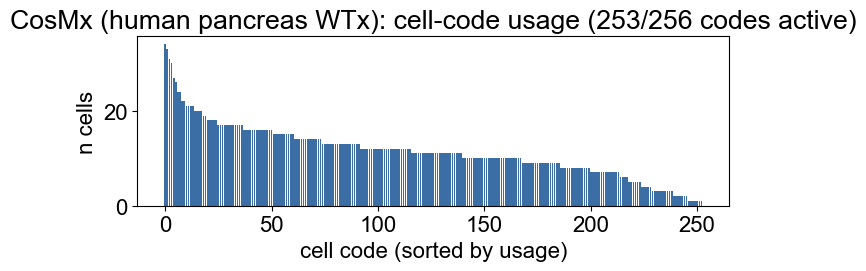

In [4]:

# --- Code-usage bar chart (how many cells fall in each active code) ---
%matplotlib inline
import matplotlib.pyplot as plt
order = np.argsort(counts)[::-1]
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(u)), counts[order], color="#3b6ea5")
ax.set_xlabel("cell code (sorted by usage)")
ax.set_ylabel("n cells")
ax.set_title(f"{PLATFORM}: cell-code usage ({len(u)}/{n_codes} codes active)")
plt.tight_layout()
plt.show()


## Top markers per code

For each used code we z-score its mean expression across codes and list the most enriched panel genes. This is a quick biological sanity check that codes track distinct cell states.

In [5]:

# --- Per-code top-marker table: mean log1p expression per code, z-scored across codes ---
import pandas as pd, scanpy as sc
work = adata.copy()
sc.pp.normalize_total(work); sc.pp.log1p(work)
X = work.X.toarray() if hasattr(work.X, "toarray") else np.asarray(work.X)
genes = np.asarray(work.var_names)
rows = []
for c in u:                                   # only codes that are actually used
    m = X[idx == c].mean(0)
    rows.append(m)
M = np.vstack(rows)                            # (n_used_codes, n_genes)
Z = (M - M.mean(0)) / (M.std(0) + 1e-8)        # z across codes, per gene
topk = 6
recs = []
for r, c in enumerate(u):
    top = genes[np.argsort(Z[r])[::-1][:topk]]
    recs.append({"cell_code": int(c), "n_cells": int((idx == c).sum()),
                 "top_markers": ", ".join(top)})
marker_tbl = pd.DataFrame(recs).sort_values("n_cells", ascending=False).reset_index(drop=True)
print(f"Top {topk} enriched genes per used cell code (first 15 codes shown):")
marker_tbl.head(15)


Top 6 enriched genes per used cell code (first 15 codes shown):


,cell_code,n_cells,top_markers
0,89,34,"SystemControl547, SystemControl24, SystemContr..."
1,4,33,"SystemControl2290, SystemControl2256, SystemCo..."
2,20,31,"SystemControl348, SystemControl1458, SystemCon..."
3,70,30,"SystemControl2553, SystemControl1389, SystemCo..."
4,96,27,"SystemControl1075, SystemControl24, SystemCont..."
5,73,26,"SystemControl1035, SystemControl429, SystemCon..."
6,186,24,"SystemControl426, SystemControl91, SystemContr..."
7,15,24,"SystemControl1345, SystemControl672, RAB38, Sy..."
8,50,22,"SystemControl667, SystemControl627, SystemCont..."
9,222,22,"SystemControl488, SystemControl1444, SystemCon..."


## Training runtime

The trainer records wall-clock time, throughput (cells/sec), and peak GPU memory to `training_runtime.json`.

In [6]:

# --- Training runtime report the trainer wrote (real timing on this GPU run) ---
rt_path = os.path.join(ckpt, "training_runtime.json")
runtime = json.load(open(rt_path))
print(json.dumps(runtime, indent=2))


{
  "total_seconds": 6.953,
  "total_hms": "0:00:06",
  "n_epochs": 20,
  "mean_epoch_seconds": 0.348,
  "cells_per_second": 8307.19,
  "iters_per_second": 5.753,
  "n_cells": 2888,
  "effective_batch_size": 2048,
  "n_batches_per_epoch": 2,
  "peak_gpu_gb": 2.551,
  "device": "cuda",
  "encoder_type": "mlp",
  "quantizer_type": "vq",
  "input_dim": 21731
}
